# COVID-19 Radiography Project — Step 6

Goal: complete the MobileNetV2 pipeline with Grad-CAM explainability.

This notebook:
- uses the same preprocessing and leakage prevention strategy,
- trains MobileNetV2 using only the training set,
- selects the best epoch using validation loss,
- evaluates the selected model on the untouched test set,
- generates Grad-CAM heatmaps for selected test images.


In [1]:
!pip -q install kagglehub

import os
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

RANDOM_STATE = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
MODEL_PATH = "mobilenetv2_gradcam_best_validation.keras"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 1. Load dataset and remove exact duplicates

In [2]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))

possible_root = dataset_path / "COVID-19_Radiography_Dataset"
data_root = possible_root if possible_root.exists() else dataset_path

class_names = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

records = []

for class_name in class_names:
    class_dir = data_root / class_name
    image_dir = class_dir / "images"
    if not image_dir.exists():
        image_dir = class_dir

    image_paths = []
    for ext in ["*.png", "*.jpg", "*.jpeg"]:
        image_paths.extend(image_dir.glob(ext))

    for path in image_paths:
        records.append({"path": str(path), "label": class_name})

df = pd.DataFrame(records)

# SHA-256 detects exact duplicate image files before splitting.
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

df["sha256"] = df["path"].apply(sha256_file)
n_duplicates = df["sha256"].duplicated().sum()

df_clean = df.drop_duplicates(subset="sha256", keep="first").reset_index(drop=True)

print("Original images:", len(df))
print("Exact duplicates removed:", n_duplicates)
print("Images after duplicate removal:", len(df_clean))
display(df_clean["label"].value_counts().loc[class_names])

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Original images: 21165
Exact duplicates removed: 54
Images after duplicate removal: 21111


,count
label,
COVID,3570
Lung_Opacity,6012
Normal,10191
Viral Pneumonia,1338


## 2. Stratified train/validation/test split

In [3]:
# Stratification preserves class proportions.
# The test set is not used during training or model selection.

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_clean["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts()
}).loc[class_names])

Train: (14777, 3)
Validation: (3167, 3)
Test: (3167, 3)


,train,validation,test
label,,,
COVID,2499,536,535
Lung_Opacity,4208,902,902
Normal,7133,1529,1529
Viral Pneumonia,937,200,201


## 3. Label encoding and image datasets

In [4]:
label_to_id = {name: i for i, name in enumerate(class_names)}
id_to_label = {i: name for name, i in label_to_id.items()}

for split_df in [train_df, val_df, test_df]:
    split_df["label_id"] = split_df["label"].map(label_to_id)

print(label_to_id)

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


In [5]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(split_df, shuffle=False):
    paths = split_df["path"].values
    labels = split_df["label_id"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=RANDOM_STATE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

images, labels = next(iter(train_ds))
print("Batch shape:", images.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Batch shape: (32, 224, 224, 3)
Pixel range: 0.0 to 1.0


## 4. Class weights

In [6]:
# Class weights are computed only from the training set.
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array(range(len(class_names))),
    y=train_df["label_id"].values
)

class_weights = {i: float(weight) for i, weight in enumerate(class_weights_values)}

for class_id, weight in class_weights.items():
    print(id_to_label[class_id], ":", round(weight, 3))

COVID : 1.478
Lung_Opacity : 0.878
Normal : 0.518
Viral Pneumonia : 3.943


## 5. Build and train MobileNetV2

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.08),
], name="data_augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet",
    name="mobilenetv2_base"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(2.0, offset=-1.0, name="mobilenet_rescaling")(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.3, name="dropout")(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax", name="classifier")(x)

model = tf.keras.Model(inputs, outputs, name="MobileNetV2_CXR_classifier")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_CXR_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_rescaling (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_base (Functional)   │ (None, 7, 7, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training choice note

The model is allowed to train for up to 30 epochs, but early stopping prevents unnecessary training.  
The best model is selected using validation loss. Because the dataset is imbalanced, the final evaluation still reports balanced accuracy, macro F1-score, sensitivity, specificity, AUROC, and AUPRC instead of relying only on accuracy.


In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

best_model = tf.keras.models.load_model(MODEL_PATH)
print("Best validation model loaded for final test evaluation and Grad-CAM.")

Epoch 1/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 63s 102ms/step - accuracy: 0.7039 - loss: 0.6423 - val_accuracy: 0.7840 - val_loss: 0.5623
Epoch 2/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - accuracy: 0.7886 - loss: 0.4603 - val_accuracy: 0.7812 - val_loss: 0.5469
Epoch 3/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.8029 - loss: 0.4234 - val_accuracy: 0.7967 - val_loss: 0.5112
Epoch 4/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.8128 - loss: 0.4130 - val_accuracy: 0.7174 - val_loss: 0.6932
Epoch 5/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.8125 - loss: 0.4079 - val_accuracy: 0.7973 - val_loss: 0.5203
Epoch 6/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.8155 - loss: 0.3951 - val_accuracy: 0.8118 - val_loss: 0.4715
Epoch 7/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.8228 - loss: 0.3868 - val_accuracy: 0.8093 - val_loss: 0.4942
Epoch 8/12
462/462 ━━━━━━━━━━━━━━━━━━━━ 47s 96ms/step - accuracy: 0.8176 - loss: 0.3931 -

## 6. Training curves

,accuracy,loss,val_accuracy,val_loss
0,0.703864,0.642330,0.784023,0.562261
1,0.788590,0.460316,0.781181,0.546887
2,0.802937,0.423378,0.796653,0.511250
3,0.812817,0.412962,0.717398,0.693165
4,0.812479,0.407913,0.797284,0.520300
5,0.815456,0.395139,0.811809,0.471544
6,0.822765,0.386783,0.809283,0.494250
7,0.817622,0.393093,0.761288,0.601209
8,0.821006,0.391148,0.787180,0.531671


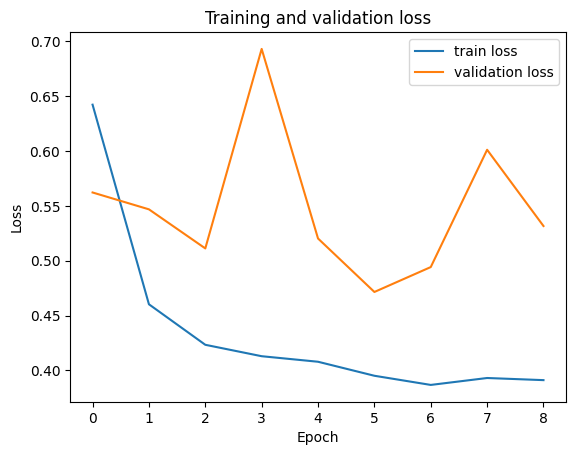

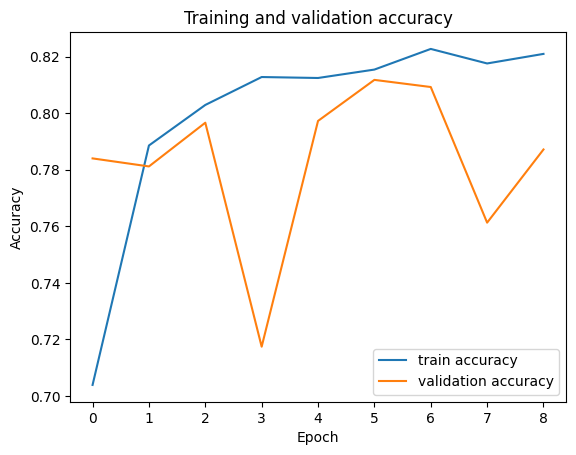

In [9]:
history_df = pd.DataFrame(history.history)
display(history_df)

plt.figure()
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

## 7. Final test evaluation

In [10]:
test_probs = best_model.predict(test_ds)
test_pred = np.argmax(test_probs, axis=1)
test_true = test_df["label_id"].values

test_accuracy = accuracy_score(test_true, test_pred)
test_balanced_accuracy = balanced_accuracy_score(test_true, test_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    test_true, test_pred, average="macro", zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    test_true, test_pred, average="weighted", zero_division=0
)

main_metrics = pd.DataFrame([{
    "Accuracy": test_accuracy,
    "Balanced accuracy": test_balanced_accuracy,
    "Macro precision": precision_macro,
    "Macro recall": recall_macro,
    "Macro F1": f1_macro,
    "Weighted precision": precision_weighted,
    "Weighted recall": recall_weighted,
    "Weighted F1": f1_weighted
}])

display(main_metrics.round(4))

print(classification_report(
    test_true, test_pred, target_names=class_names, digits=4, zero_division=0
))

99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step


,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1,Weighted precision,Weighted recall,Weighted F1
0,0.8184,0.8567,0.782,0.8567,0.8101,0.8358,0.8184,0.8215


                 precision    recall  f1-score   support

          COVID     0.6449    0.8486    0.7328       535
   Lung_Opacity     0.8446    0.8016    0.8225       902
         Normal     0.9117    0.7966    0.8503      1529
Viral Pneumonia     0.7269    0.9801    0.8347       201

       accuracy                         0.8184      3167
      macro avg     0.7820    0.8567    0.8101      3167
   weighted avg     0.8358    0.8184    0.8215      3167



## Majority baseline

This baseline always predicts the most frequent class in the training set.  
It is included as a reference floor to show that the CNN is learning more than the class imbalance.


In [ ]:
# Majority baseline: always predict the most frequent class from the training set.
# This uses only training labels to define the baseline class.

majority_class = train_df["label_id"].mode()[0]
baseline_pred = np.full_like(test_true, fill_value=majority_class)

baseline_metrics = pd.DataFrame([{
    "Model": "Majority baseline",
    "Majority class": id_to_label[majority_class],
    "Accuracy": accuracy_score(test_true, baseline_pred),
    "Balanced accuracy": balanced_accuracy_score(test_true, baseline_pred)
}])

display(baseline_metrics.round(4))

print("Majority class:", id_to_label[majority_class])
print(classification_report(
    test_true,
    baseline_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

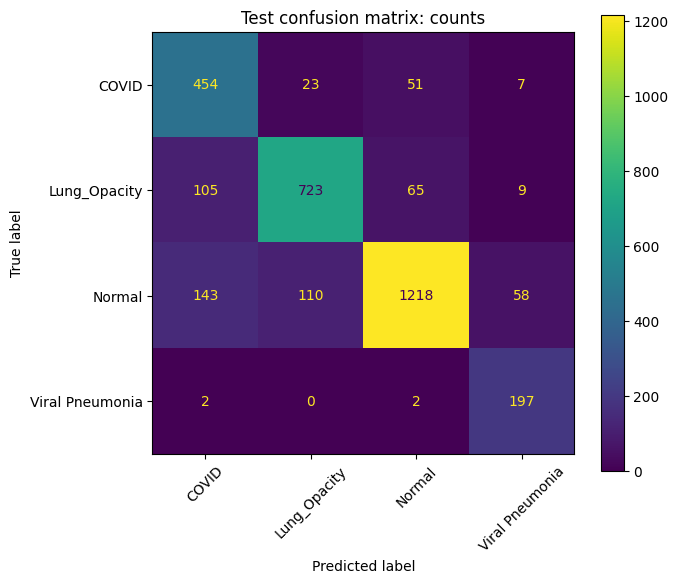

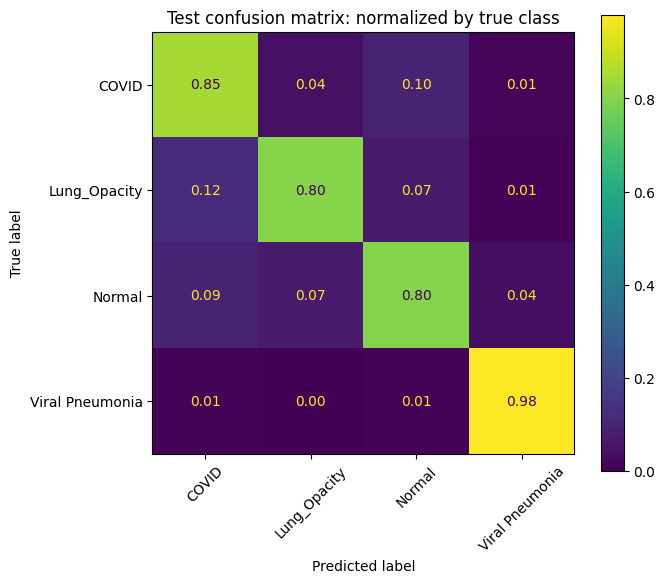

In [11]:
cm = confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Test confusion matrix: counts")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(test_true, test_pred, normalize="true")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp_norm.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Test confusion matrix: normalized by true class")
plt.tight_layout()
plt.show()

## 8. Grad-CAM helper functions

In [15]:
def preprocess_single_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def make_gradcam_heatmap(model, image_tensor, class_index=None, last_conv_layer_name="Conv_1"):
    # Keras can give graph errors when Grad-CAM is built directly from a nested model.
    # Therefore, we explicitly pass the image through the same inference path:
    # image -> MobileNet rescaling -> MobileNetV2 base -> GAP -> Dropout -> classifier.

    base_model = model.get_layer("mobilenetv2_base")
    rescaling_layer = model.get_layer("mobilenet_rescaling")
    gap_layer = model.get_layer("global_average_pooling")
    dropout_layer = model.get_layer("dropout")
    classifier_layer = model.get_layer("classifier")

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    image_batch = tf.expand_dims(image_tensor, axis=0)

    with tf.GradientTape() as tape:
        x = rescaling_layer(image_batch)
        conv_outputs, base_outputs = conv_model(x, training=False)

        x = gap_layer(base_outputs)
        x = dropout_layer(x, training=False)
        predictions = classifier_layer(x)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()[0]

def overlay_heatmap(image_tensor, heatmap, alpha=0.4):
    image = image_tensor.numpy()

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE
    ).numpy().squeeze()

    cmap = plt.get_cmap("jet")
    heatmap_rgb = cmap(heatmap_resized)[..., :3]

    overlay = (1 - alpha) * image + alpha * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)

    return overlay

## 9. Grad-CAM for correctly classified test images

In [16]:
test_results = test_df[["path", "label", "label_id"]].copy()
test_results["pred_id"] = test_pred
test_results["pred_label"] = [id_to_label[i] for i in test_pred]
test_results["correct"] = test_results["label_id"] == test_results["pred_id"]
test_results["confidence"] = np.max(test_probs, axis=1)

correct_examples = (
    test_results[test_results["correct"] == True]
    .sort_values("confidence", ascending=False)
    .groupby("label", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

display(correct_examples[["label", "pred_label", "confidence"]])

,label,pred_label,confidence
0,Viral Pneumonia,Viral Pneumonia,0.999999
1,COVID,COVID,0.999954
2,Lung_Opacity,Lung_Opacity,0.999830
3,Normal,Normal,0.997017


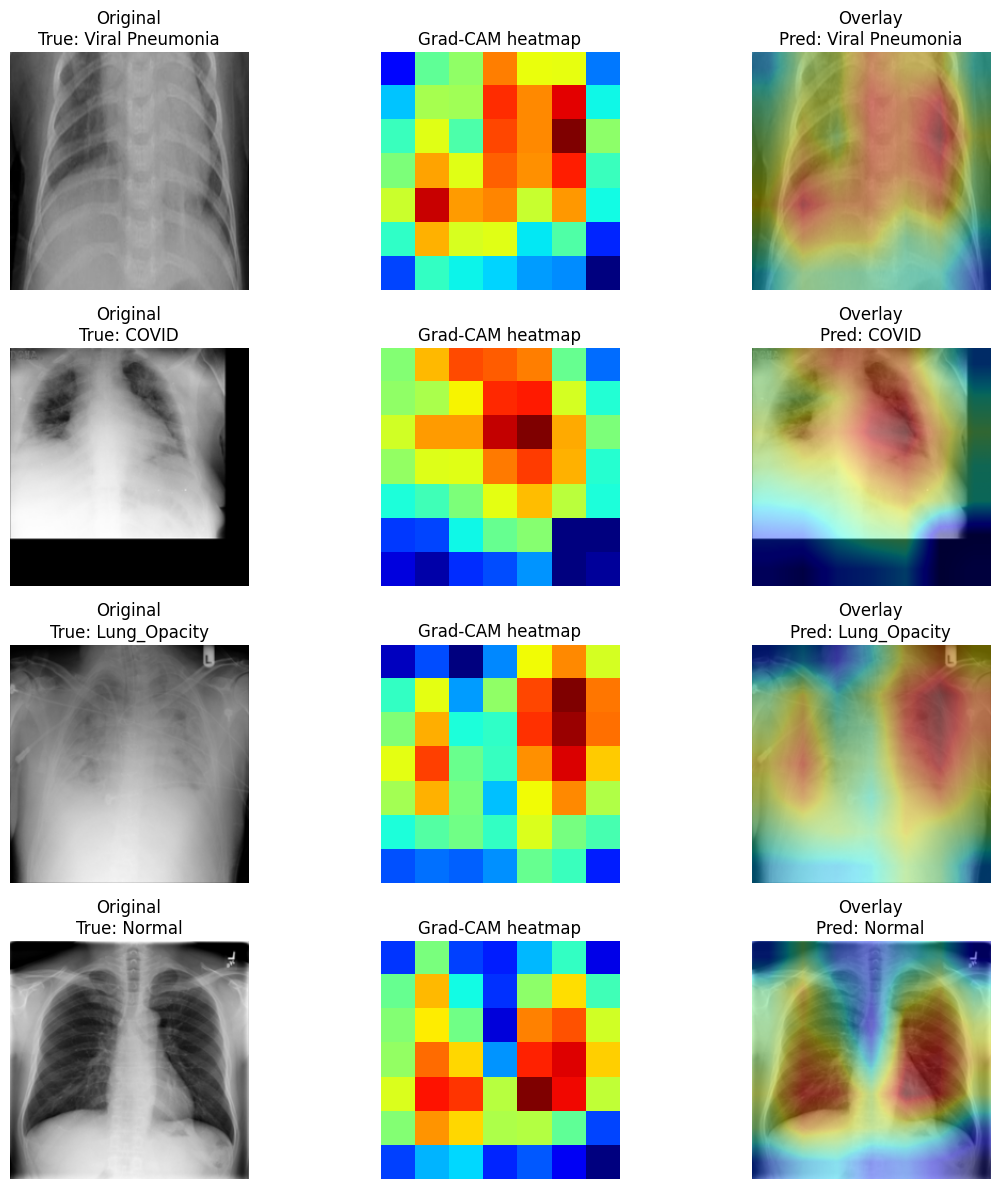

In [17]:
n = len(correct_examples)
plt.figure(figsize=(12, 3 * n))

for i, (_, row) in enumerate(correct_examples.iterrows()):
    image_tensor = preprocess_single_image(row["path"])
    heatmap, probs = make_gradcam_heatmap(best_model, image_tensor, class_index=int(row["pred_id"]))
    overlay = overlay_heatmap(image_tensor, heatmap)

    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(image_tensor.numpy())
    plt.title(f"Original\nTrue: {row['label']}")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM heatmap")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPred: {row['pred_label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Grad-CAM for high-confidence errors

In [18]:
mistakes = (
    test_results[test_results["correct"] == False]
    .sort_values("confidence", ascending=False)
    .head(4)
    .reset_index(drop=True)
)

print("Number of test errors:", len(test_results[test_results["correct"] == False]))
display(mistakes[["label", "pred_label", "confidence"]])

Number of test errors: 575


,label,pred_label,confidence
0,Normal,Viral Pneumonia,0.996260
1,Normal,Viral Pneumonia,0.994869
2,Normal,Viral Pneumonia,0.991861
3,Normal,Viral Pneumonia,0.990112


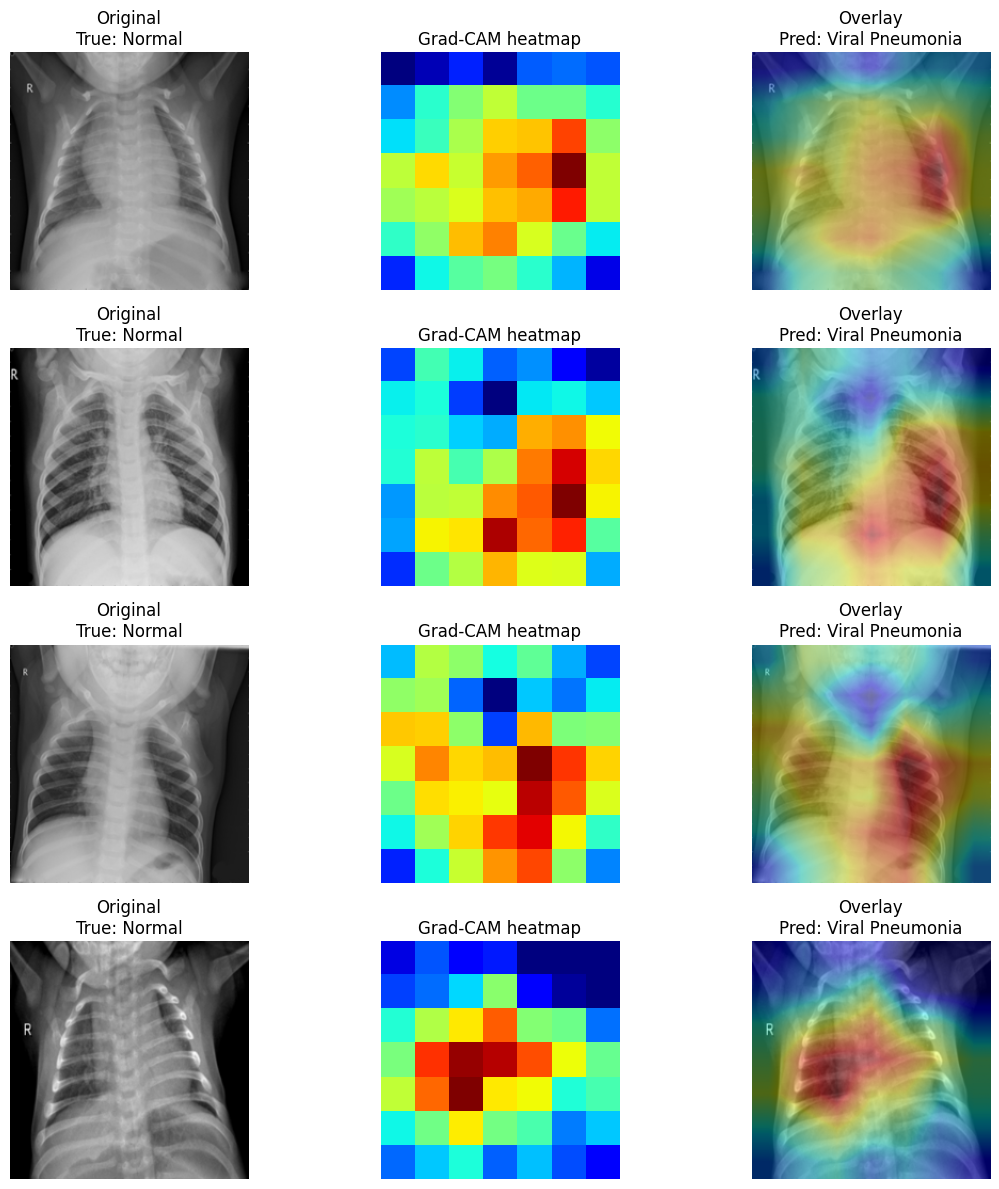

In [19]:
if len(mistakes) > 0:
    n = len(mistakes)
    plt.figure(figsize=(12, 3 * n))

    for i, (_, row) in enumerate(mistakes.iterrows()):
        image_tensor = preprocess_single_image(row["path"])
        heatmap, probs = make_gradcam_heatmap(best_model, image_tensor, class_index=int(row["pred_id"]))
        overlay = overlay_heatmap(image_tensor, heatmap)

        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(image_tensor.numpy())
        plt.title(f"Original\nTrue: {row['label']}")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(heatmap, cmap="jet")
        plt.title("Grad-CAM heatmap")
        plt.axis("off")

        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(overlay)
        plt.title(f"Overlay\nPred: {row['pred_label']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples found.")

## 11. Save outputs

In [20]:
test_results.to_csv("mobilenetv2_gradcam_test_predictions.csv", index=False)
main_metrics.to_csv("mobilenetv2_gradcam_test_metrics.csv", index=False)
history_df.to_csv("mobilenetv2_gradcam_training_history.csv", index=False)

print("Saved:")
print("- mobilenetv2_gradcam_best_validation.keras")
print("- mobilenetv2_gradcam_test_predictions.csv")
print("- mobilenetv2_gradcam_test_metrics.csv")
print("- mobilenetv2_gradcam_training_history.csv")

Saved:
- mobilenetv2_gradcam_best_validation.keras
- mobilenetv2_gradcam_test_predictions.csv
- mobilenetv2_gradcam_test_metrics.csv
- mobilenetv2_gradcam_training_history.csv


Report note:
Grad-CAM is a qualitative explainability method. It can show which image regions influenced the model prediction, but it does not prove clinical lesion localization.


## Report notes about methodology

For the report, mention:
- Exact duplicates were removed using SHA-256 before splitting.
- Near-duplicate images were not aggressively removed because visually similar chest X-rays may be valid images from different patients.
- The test set was kept untouched and used only for final evaluation.
- The best model was selected using validation loss.
- Since the dataset is imbalanced, balanced accuracy and macro F1-score are emphasized.
- A limitation is that the final deep learning model was trained with one fixed seed; future work could repeat training with multiple seeds and report mean ± standard deviation.
